Dataset shape: (19628, 35)

Missing values per column:
application_id                0
customer_id                   0
application_date              0
gender                        0
race                          0
age                           0
age_group                     0
region                        0
marital_status                0
residence_type                0
education_level               0
employment_status             0
industry                      0
employer_desc                 0
income_annual               623
avg_account_age_months        0
num_credit_cards              0
num_inquiries_6m              0
delinq_2y                  1076
zip3                          0
application_channel           0
device_type                   0
loan_purpose                  0
loan_amount                   0
dti                           0
utilization_rate              0
revolving_balance             0
credit_score                203
approval_score                0
approved         

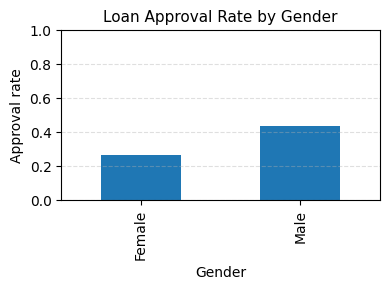

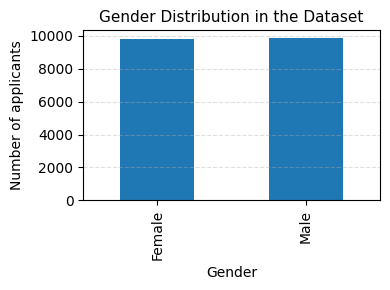

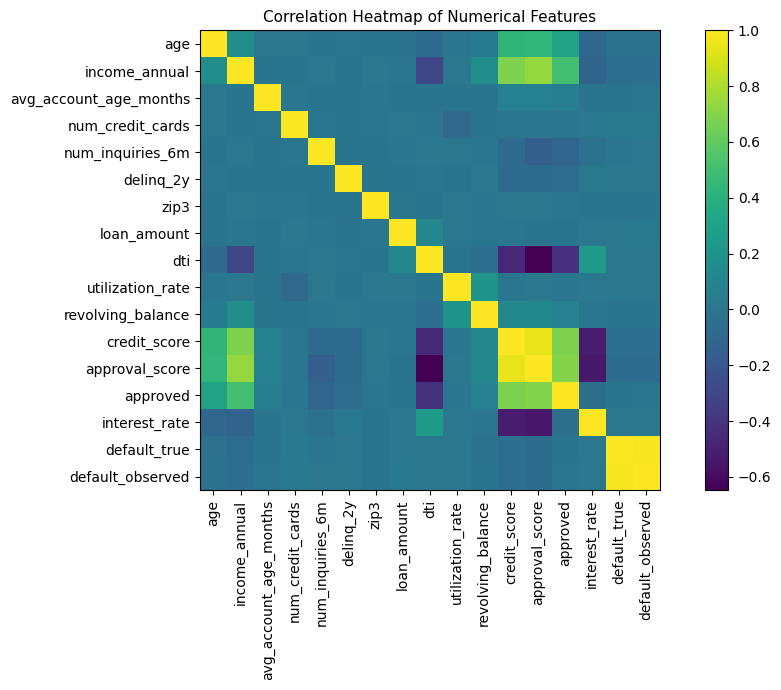

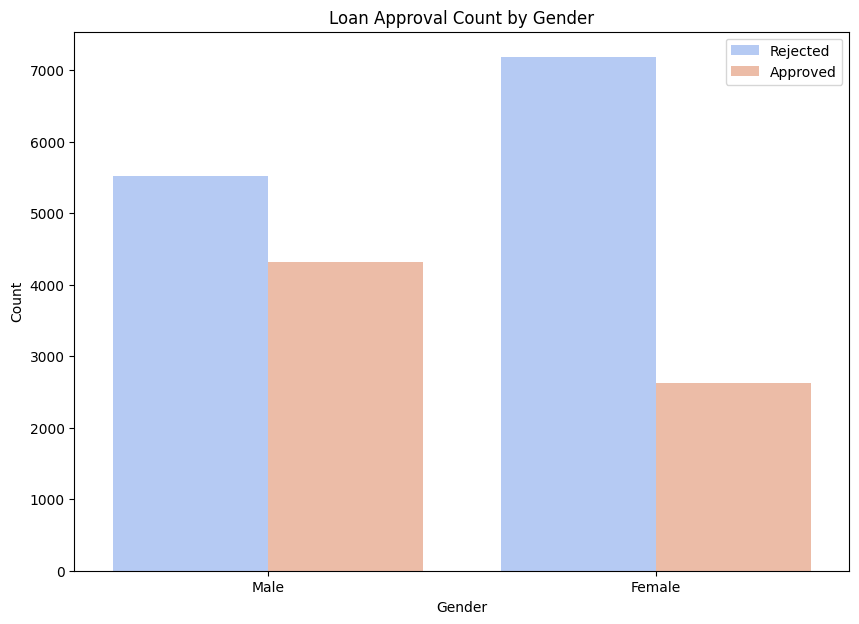

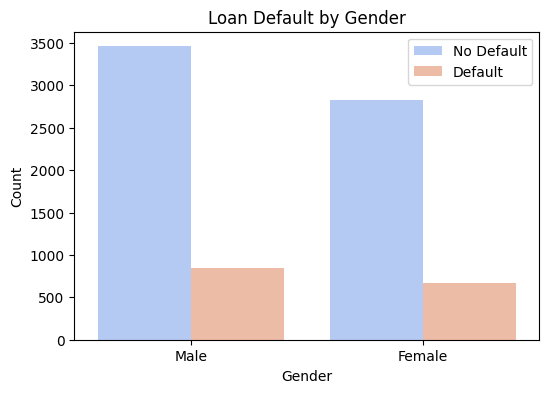

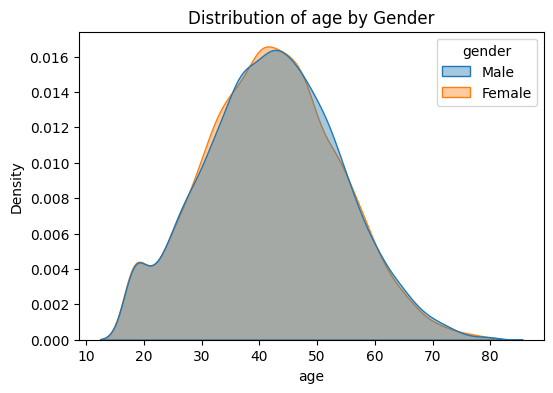

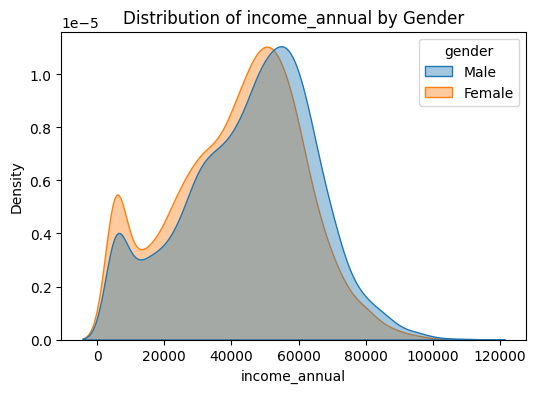

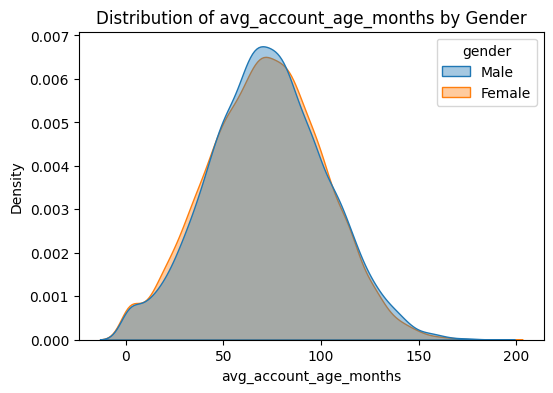

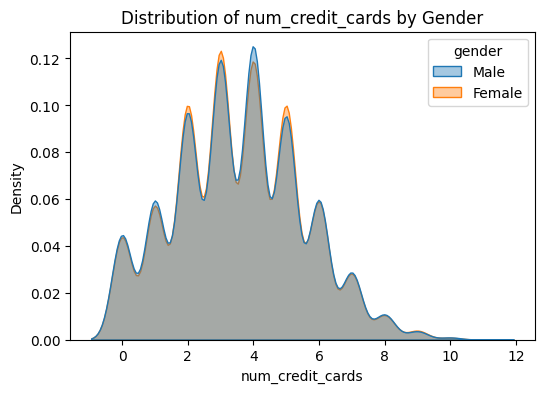

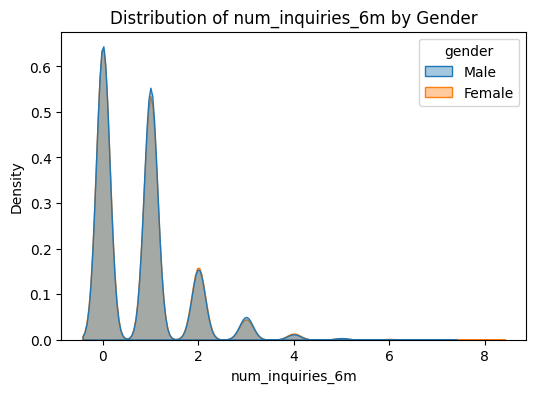

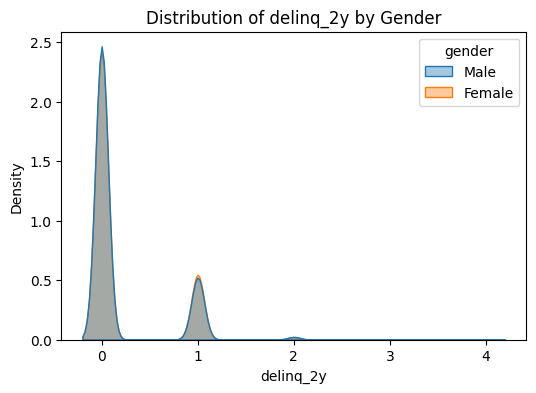

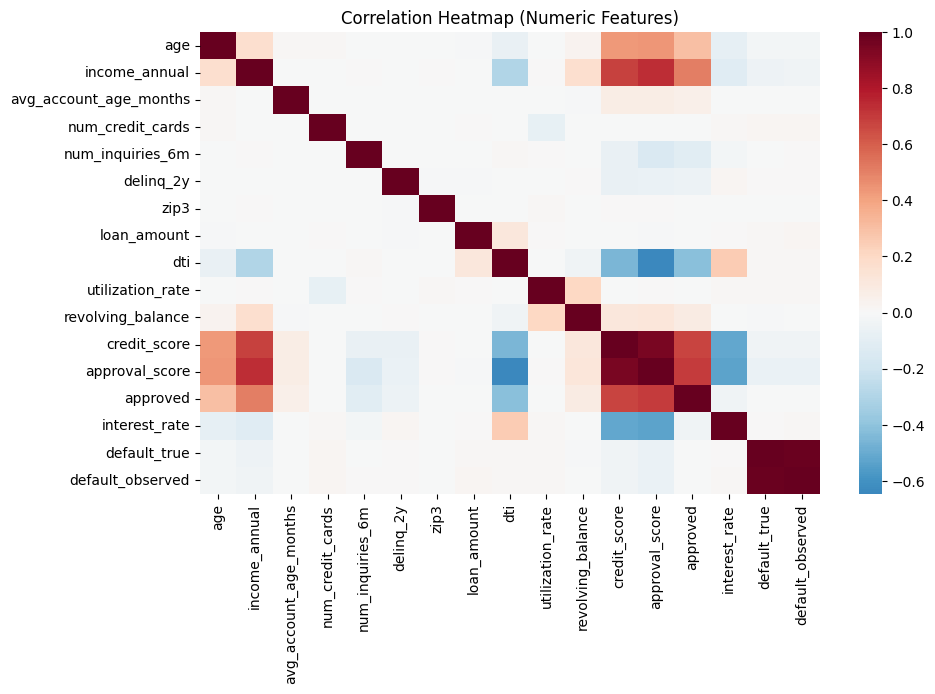

Approval Rate (Male): 0.439
Approval Rate (Female): 0.268
Statistical Parity Difference (SPD): -0.171
Disparate Impact (DI): 0.611


('fairness_accuracy_comparison.csv', 'fairness_vs_accuracy_tradeoff.png')

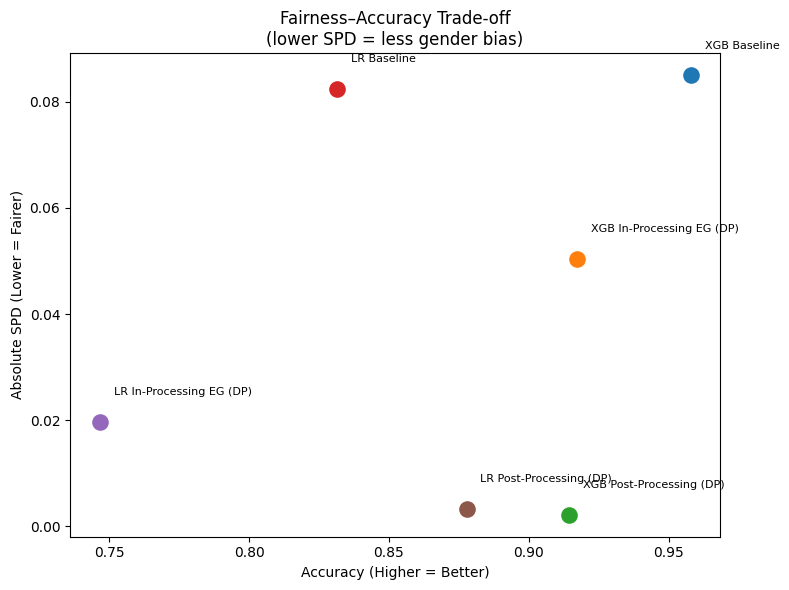

In [1]:
# Full pipeline: compare XGB and LR on biased dataset and generate results and plot.
!pip install pandas numpy scikit-learn xgboost fairlearn matplotlib

import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer

# File path
PATH = "complex_credit_scoring_bias_dataset_biased.csv"

df = pd.read_csv(PATH)
df["gender"] = df["gender"].astype(str).str.strip().str.title()
df = df[df["gender"].isin(["Male","Female"])].copy()

TARGET = "approved"
SENSITIVE = "gender"

# --- EDA and Visualizations ---

# Display basic info
print("Dataset shape:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())

print("\nGender distribution:")
print(df["gender"].value_counts())

print("\nTarget (approved) distribution:")
print(df["approved"].value_counts())

# Basic numerical overview
df.describe(include="all").T

# approval rate by gender
approval_by_gender = df.groupby("gender")["approved"].mean().sort_index()

fig, ax = plt.subplots(figsize=(4, 3))
approval_by_gender.plot(kind="bar", ax=ax)

ax.set_title("Loan Approval Rate by Gender", fontsize=11)
ax.set_xlabel("Gender")
ax.set_ylabel("Approval rate")
ax.set_ylim(0, 1)  # since it's a probability
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_approval_by_gender.png", dpi=300)
plt.show()

gender_counts = df["gender"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(4, 3))
gender_counts.plot(kind="bar", ax=ax)

ax.set_title("Gender Distribution in the Dataset", fontsize=11)
ax.set_xlabel("Gender")
ax.set_ylabel("Number of applicants")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("fig_gender_distribution.png", dpi=300)
plt.show()


# select numerical columns (you can also define num_cols manually)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 7))
cax = ax.imshow(corr, interpolation="nearest")
# axis ticks
ax.set_xticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=90)
ax.set_yticks(range(len(num_cols)))
ax.set_yticklabels(num_cols)

# colorbar
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.05)
ax.set_title("Correlation Heatmap of Numerical Features", fontsize=11)
plt.tight_layout()
plt.savefig("fig_corr_heatmap.png", dpi=300)
plt.show()

# Gender vs Loan Approval
plt.figure(figsize=(10,7))
sns.countplot(x="gender", hue="approved", data=df, palette="coolwarm")
plt.title("Loan Approval Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(["Rejected", "Approved"])
plt.show()

# Gender vs Default
if "default_observed" in df.columns:
    plt.figure(figsize=(6,4))
    sns.countplot(x="gender", hue="default_observed", data=df, palette="coolwarm")
    plt.title("Loan Default by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Count")
    plt.legend(["No Default", "Default"])
    plt.show()

# Plot numeric feature distributions by gender
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ["approved", "gender_num", "default_observed"]]

for col in numeric_cols[:6]:  # limit to first 6 to avoid clutter
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue="gender", fill=True, alpha=0.4)
    plt.title(f"Distribution of {col} by Gender")
    plt.show()

# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


# Calculate simple statistical parity before training
group_means = df.groupby("gender")["approved"].mean()
spd = group_means["Female"] - group_means["Male"]
di = group_means["Female"] / group_means["Male"]

print(f"Approval Rate (Male): {group_means['Male']:.3f}")
print(f"Approval Rate (Female): {group_means['Female']:.3f}")
print(f"Statistical Parity Difference (SPD): {spd:.3f}")
print(f"Disparate Impact (DI): {di:.3f}")

bias_summary = pd.DataFrame({
    "Gender": ["Male", "Female"],
    "Approval Rate": [group_means["Male"], group_means["Female"]],
})

# Preprocess
def prep(df):
    d = df.copy()
    d = d[~d[TARGET].isna()].copy()
    drop = {TARGET, SENSITIVE, "application_id","customer_id","underwriter_notes","employer_desc",
            "intersectional_group","application_date"}
    drop |= set([c for c in d.columns if "gender" in c.lower()])
    feats = [c for c in d.columns if c not in drop]

    cat = d[feats].select_dtypes(include="object").columns.tolist()
    num = [c for c in feats if c not in cat]

    for c in num:
        d[c] = pd.to_numeric(d[c], errors="coerce")
        d[c] = d[c].fillna(d[c].median())
    if cat:
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        d[cat] = enc.fit_transform(d[cat].astype(str))

    X = d[feats].reset_index(drop=True)
    y = d[TARGET].astype(int).reset_index(drop=True)
    A = df.loc[X.index, SENSITIVE].reset_index(drop=True)
    return X,y,A

X,y,A = prep(df)
X_tr, X_te, y_tr, y_te, A_tr, A_te = train_test_split(X,y,A,test_size=0.3,random_state=42,stratify=y)

def summarize(y_true, y_pred, A_sens, y_prob=None, label="model"):
    acc = accuracy_score(y_true,y_pred)
    auc = roc_auc_score(y_true,y_prob) if y_prob is not None else None
    # SPD and DI
    y_pred = pd.Series(y_pred, index=A_sens.index)
    rates = y_pred.groupby(A_sens).mean()
    male = rates.get("Male",np.nan)
    female = rates.get("Female",np.nan)
    spd = float(female - male)
    di = float(female / male) if male>0 else np.nan
    return {"Model":label,"ACC":acc,"AUC":auc,"SPD":spd,"DI":di}

results = []

# XGB Baseline
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, subsample=0.85, colsample_bytree=0.85, eval_metric="logloss")
xgb.fit(X_tr,y_tr)
p = xgb.predict_proba(X_te)[:,1]
yhat = (p>=0.5).astype(int)
results.append(summarize(y_te,yhat,A_te,p,"XGB Baseline"))

# XGB In-Processing (EG DP)
eg = ExponentiatedGradient(estimator=XGBClassifier(n_estimators=80,max_depth=3,learning_rate=0.12,eval_metric="logloss"),
                           constraints=DemographicParity())
eg.fit(X_tr,y_tr,sensitive_features=A_tr)
yhat_eg = eg.predict(X_te)
results.append(summarize(y_te,yhat_eg,A_te,None,"XGB In-Processing EG (DP)"))

# XGB Post-Processing DP w/ Calibration
cal = CalibratedClassifierCV(xgb, method="isotonic", cv=5)
cal.fit(X_tr,y_tr)
post = ThresholdOptimizer(estimator=cal,constraints="demographic_parity",
                          objective="balanced_accuracy_score",predict_method="predict_proba",prefit=True)
post.fit(X_tr,y_tr,sensitive_features=A_tr)
yhat_post = post.predict(X_te,sensitive_features=A_te)
results.append(summarize(y_te,yhat_post,A_te,None,"XGB Post-Processing (DP)"))

# Logistic Regression Baseline
lr = LogisticRegression(max_iter=500,solver="liblinear")
lr.fit(X_tr,y_tr)
p_lr = lr.predict_proba(X_te)[:,1]
yhat_lr = (p_lr>=0.5).astype(int)
results.append(summarize(y_te,yhat_lr,A_te,p_lr,"LR Baseline"))

# LR In-Processing (EG DP)
eg_lr = ExponentiatedGradient(estimator=LogisticRegression(max_iter=500,solver="liblinear"),
                              constraints=DemographicParity())
eg_lr.fit(X_tr,y_tr,sensitive_features=A_tr)
yhat_lr_eg = eg_lr.predict(X_te)
results.append(summarize(y_te,yhat_lr_eg,A_te,None,"LR In-Processing EG (DP)"))

# LR Post-Processing
cal_lr = CalibratedClassifierCV(lr,method="isotonic",cv=5)
cal_lr.fit(X_tr,y_tr)
post_lr = ThresholdOptimizer(estimator=cal_lr,constraints="demographic_parity",
                             objective="balanced_accuracy_score",predict_method="predict_proba",prefit=True)
post_lr.fit(X_tr,y_tr,sensitive_features=A_tr)
yhat_lr_post = post_lr.predict(X_te,sensitive_features=A_te)
results.append(summarize(y_te,yhat_lr_post,A_te,None,"LR Post-Processing (DP)"))

df_res = pd.DataFrame(results)
df_res.to_csv("fairness_accuracy_comparison.csv", index=False)

# Fairness vs Accuracy Plot
plt.figure(figsize=(8,6))
for _, row in df_res.iterrows():
    plt.scatter(row["ACC"], abs(row["SPD"]), s=120)
    plt.text(row["ACC"]+0.005, abs(row["SPD"])+0.005, row["Model"], fontsize=8)

plt.xlabel("Accuracy (Higher = Better)")
plt.ylabel("Absolute SPD (Lower = Fairer)")
plt.title("Fairness–Accuracy Trade-off\n(lower SPD = less gender bias)")
plt.tight_layout()
plt.savefig("fairness_vs_accuracy_tradeoff.png", dpi=200)

"fairness_accuracy_comparison.csv", "fairness_vs_accuracy_tradeoff.png"


In [2]:
# Helper function definitions for this cell
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# DATA_PATH and OUTDIR
DATA_PATH = "complex_credit_scoring_bias_dataset_biased.csv" # Using the same as PATH from previous cell
OUTDIR = Path("fairness_outputs") # Define output directory
OUTDIR.mkdir(exist_ok=True) # Create if it doesn't exist

def print_block(results_dict):
    """Prints a dictionary of results in a formatted way."""
    for k, v in results_dict.items():
        if isinstance(v, float):
            print(f"{k}: {v:.4f}")
        elif isinstance(v, dict):
            print(f"{k}:")
            for sub_k, sub_v in v.items():
                if isinstance(sub_v, float):
                    print(f"  {sub_k}: {sub_v:.4f}")
                else:
                    print(f"  {sub_k}: {sub_v}")
        else:
            print(f"{k}: {v}")
    print("-" * 30)

def summarize(y_true, y_pred, A_sens, y_prob=None, label="model"):
    """
    Summarizes fairness and accuracy metrics.
    Assumes A_sens is a pandas Series with 'Male' and 'Female' categories.
    """
    results = {"Step": label}

    # Accuracy and AUC
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    results["ACC"] = acc
    results["AUC"] = auc

    # Statistical Parity Difference (SPD) and Disparate Impact (DI)
    # Selection rate P(Y_pred=1 | A=a)
    y_pred_series = pd.Series(y_pred, index=A_sens.index)
    selection_rates_by_gender = y_pred_series.groupby(A_sens).mean()

    male_sel_rate = selection_rates_by_gender.get("Male", 0)
    female_sel_rate = selection_rates_by_gender.get("Female", 0)

    spd = float(female_sel_rate - male_sel_rate)
    di = float(female_sel_rate / male_sel_rate) if male_sel_rate > 0 else np.nan
    results["SPD(F-M)"] = spd
    results["DI(F/M)"] = di
    results["SelRate_by_gender"] = {"Male": male_sel_rate, "Female": female_sel_rate}

    # Equal Opportunity Difference (EOD)
    # P(Y_pred=1 | Y=1, A=a)
    tpr_by_gender = {}
    for group_name in A_sens.unique():
        group_mask = (A_sens == group_name)
        true_positives_mask = (y_true[group_mask] == 1)
        if true_positives_mask.sum() > 0: # Avoid division by zero
            tpr = ((y_pred[group_mask] == 1) & (y_true[group_mask] == 1)).sum() / true_positives_mask.sum()
            tpr_by_gender[group_name] = tpr
        else:
            tpr_by_gender[group_name] = np.nan

    male_tpr = tpr_by_gender.get("Male", np.nan)
    female_tpr = tpr_by_gender.get("Female", np.nan)
    results["EOD"] = float(female_tpr - male_tpr) if not np.isnan(female_tpr) and not np.isnan(male_tpr) else np.nan

    # Confusion Matrix by Gender
    confusion_by_gender = {}
    for group_name in A_sens.unique():
        group_mask = (A_sens == group_name)
        tn, fp, fn, tp = [0,0,0,0] # Default to zero if group is empty
        if group_mask.sum() > 0:
            tn, fp, fn, tp = confusion_matrix(y_true[group_mask], y_pred[group_mask], labels=[0,1]).ravel()
        confusion_by_gender[group_name] = {"TP": tp, "FP": fp, "TN": tn, "FN": fn}
    results["Confusion_by_gender"] = confusion_by_gender

    return results

def compute_reweigh_weights(A_sens, y_true):
    """
    Computes reweighing weights to achieve fairness.
    Weights are calculated such that each (sensitive_attribute_value, target_value)
    combination effectively has the same total weight (proportional to overall distributions).
    """
    weights = np.ones(len(y_true))
    total_samples = len(y_true)

    unique_A = A_sens.unique()
    unique_y = y_true.unique()

    p_y = y_true.value_counts(normalize=True)
    p_a = A_sens.value_counts(normalize=True)

    for a_val in unique_A:
        for y_val in unique_y:
            mask = (A_sens == a_val) & (y_true == y_val)
            count_ay = mask.sum()
            if count_ay > 0:
                p_ay = count_ay / total_samples
                if p_ay > 0:
                    weight_val = (p_y.get(y_val, 0) * p_a.get(a_val, 0)) / p_ay
                    weights[mask] = weight_val
                else:
                    weights[mask] = 0
    weights = weights / weights.sum() * total_samples
    return weights

all_rows = []

# =========================
# XGBoost pipeline
# =========================
xgb_base = XGBClassifier(
    n_estimators=180, max_depth=4, learning_rate=0.10,
    subsample=0.85, colsample_bytree=0.85, eval_metric="logloss",
    random_state=42, n_jobs=-1
)
xgb_base.fit(X_tr, y_tr)
p_xgb = xgb_base.predict_proba(X_te)[:,1]
yhat_xgb = (p_xgb >= 0.5).astype(int)
res = summarize(y_te, yhat_xgb, A_te, p_xgb, "[XGB] Baseline")
print_block(res); all_rows.append({"Model":"XGB", **{k:v for k,v in res.items() if k!='Step'}, "Step":res["Step"]})

# Reweighing
w = compute_reweigh_weights(A_tr, y_tr)
xgb_rw = XGBClassifier(**xgb_base.get_params())
xgb_rw.fit(X_tr, y_tr, sample_weight=w)
p_xgb_rw = xgb_rw.predict_proba(X_te)[:,1]
yhat_xgb_rw = (p_xgb_rw >= 0.5).astype(int)
res = summarize(y_te, yhat_xgb_rw, A_te, p_xgb_rw, "[XGB] Reweighing")
print_block(res); all_rows.append({"Model":"XGB", **{k:v for k,v in res.items() if k!='Step'}, "Step":res["Step"]})

# In-Processing EG (if fairlearn is available)
try:
    from fairlearn.reductions import ExponentiatedGradient, DemographicParity
    eg_xgb = ExponentiatedGradient(
        estimator=XGBClassifier(n_estimators=80, max_depth=3, learning_rate=0.12, eval_metric="logloss", random_state=42, n_jobs=-1),
        constraints=DemographicParity()
    )
    eg_xgb.fit(X_tr, y_tr, sensitive_features=A_tr)
    yhat_eg_xgb = eg_xgb.predict(X_te)
    res = summarize(y_te, yhat_eg_xgb, A_te, None, "[XGB] In-Proc EG (DP)")
    print_block(res); all_rows.append({"Model":"XGB", **{k:v for k,v in res.items() if k!='Step'}, "Step":res["Step"]})
except Exception as e:
    print("\n[Info] fairlearn not available: skipping [XGB] In-Proc EG (DP).", e)

# Post-Processing ThresholdOptimizer (if fairlearn is available)
try:
    from fairlearn.postprocessing import ThresholdOptimizer
    cal_xgb = CalibratedClassifierCV(xgb_base, method="isotonic", cv=5)
    cal_xgb.fit(X_tr, y_tr)
    post_xgb = ThresholdOptimizer(
        estimator=cal_xgb, constraints="demographic_parity",
        objective="balanced_accuracy_score", predict_method="predict_proba", prefit=True, grid_size=400
    )
    post_xgb.fit(X_tr, y_tr, sensitive_features=A_tr)
    yhat_post_xgb = post_xgb.predict(X_te, sensitive_features=A_te)
    res = summarize(y_te, yhat_post_xgb, A_te, None, "[XGB] Post-Proc (DP, calibrated)")
    print_block(res); all_rows.append({"Model":"XGB", **{k:v for k,v in res.items() if k!='Step'}, "Step":res["Step"]})
except Exception as e:
    print("\n[Info] fairlearn not available: skipping [XGB] Post-Proc (DP).", e)

# =========================
# Logistic Regression pipeline
# =========================
lr_base = LogisticRegression(max_iter=600, solver="liblinear")
lr_base.fit(X_tr, y_tr)
p_lr = lr_base.predict_proba(X_te)[:,1]
yhat_lr = (p_lr >= 0.5).astype(int)
res = summarize(y_te, yhat_lr, A_te, p_lr, "[LR] Baseline")
print_block(res); all_rows.append({"Model":"LR", **{k:v for k,v in res.items() if k!='Step'}, "Step":res["Step"]})

# Reweighing
lr_rw = LogisticRegression(max_iter=600, solver="liblinear")
lr_rw.fit(X_tr, y_tr, sample_weight=w)
p_lr_rw = lr_rw.predict_proba(X_te)[:,1]
yhat_lr_rw = (p_lr_rw >= 0.5).astype(int)
res = summarize(y_te, yhat_lr_rw, A_te, p_lr_rw, "[LR] Reweighing")
print_block(res); all_rows.append({"Model":"LR", **{k:v for k,v in res.items() if k!='Step'}, "Step":res["Step"]})

# In-Processing EG (if fairlearn is available)
try:
    from fairlearn.reductions import ExponentiatedGradient, DemographicParity
    eg_lr = ExponentiatedGradient(estimator=LogisticRegression(max_iter=600, solver="liblinear"),
                                  constraints=DemographicParity())
    eg_lr.fit(X_tr, y_tr, sensitive_features=A_tr)
    yhat_eg_lr = eg_lr.predict(X_te)
    res = summarize(y_te, yhat_eg_lr, A_te, None, "[LR] In-Proc EG (DP)")
    print_block(res); all_rows.append({"Model":"LR", **{k:v for k,v in res.items() if k!='Step'}, "Step":res["Step"]})
except Exception as e:
    print("\n[Info] fairlearn not available: skipping [LR] In-Proc EG (DP).", e)

# Post-Processing ThresholdOptimizer (if fairlearn is available)
try:
    from fairlearn.postprocessing import ThresholdOptimizer
    cal_lr = CalibratedClassifierCV(lr_base, method="isotonic", cv=5)
    cal_lr.fit(X_tr, y_tr)
    post_lr = ThresholdOptimizer(
        estimator=cal_lr, constraints="demographic_parity",
        objective="balanced_accuracy_score", predict_method="predict_proba", prefit=True, grid_size=400
    )
    post_lr.fit(X_tr, y_tr, sensitive_features=A_tr)
    yhat_lr_post = post_lr.predict(X_te, sensitive_features=A_te)
    res = summarize(y_te, yhat_lr_post, A_te, None, "[LR] Post-Proc (DP, calibrated)")
    print_block(res); all_rows.append({"Model":"LR", **{k:v for k,v in res.items() if k!='Step'}, "Step":res["Step"]})
except Exception as e:
    print("\n[Info] fairlearn not available: skipping [LR] Post-Proc (DP).", e)

# --- Save a tidy CSV of results ---
rows_for_csv = []
for r in all_rows:
    rows_for_csv.append({
        "ModelFamily": r["Model"],
        "Step": r["Step"],
        "ACC": r["ACC"],
        "AUC": r["AUC"] if not np.isnan(r["AUC"]) else "",
        "SPD(F-M)": r["SPD(F-M)"],
        "DI(F/M)": r["DI(F/M)"],
        "EOD": r["EOD"],
        "SelRate_Male": r["SelRate_by_gender"].get("Male", np.nan),
        "SelRate_Female": r["SelRate_by_gender"].get("Female", np.nan),
        "TP_Male": r["Confusion_by_gender"]["Male"]["TP"],
        "FP_Male": r["Confusion_by_gender"]["Male"]["FP"],
        "TN_Male": r["Confusion_by_gender"]["Male"]["TN"],
        "FN_Male": r["Confusion_by_gender"]["Male"]["FN"],
        "TP_Female": r["Confusion_by_gender"]["Female"]["TP"],
        "FP_Female": r["Confusion_by_gender"]["Female"]["FP"],
        "TN_Female": r["Confusion_by_gender"]["Female"]["TN"],
        "FN_Female": r["Confusion_by_gender"]["Female"]["FN"],
        "DataPath": DATA_PATH
    })

df_out = pd.DataFrame(rows_for_csv)
csv_path = OUTDIR / "per_step_results.csv"
df_out.to_csv(csv_path, index=False)


Step: [XGB] Baseline
ACC: 0.9579
AUC: 0.9698
SPD(F-M): -0.0850
DI(F/M): 0.8054
SelRate_by_gender:
  Male: 0.4368
  Female: 0.3518
EOD: 0.0003
Confusion_by_gender:
  Male: {'TP': np.int64(1290), 'FP': np.int64(0), 'TN': np.int64(1661), 'FN': np.int64(2)}
  Female: {'TP': np.int64(788), 'FP': np.int64(245), 'TN': np.int64(1902), 'FN': np.int64(1)}
------------------------------
Step: [XGB] Reweighing
ACC: 0.9581
AUC: 0.9694
SPD(F-M): -0.0853
DI(F/M): 0.8046
SelRate_by_gender:
  Male: 0.4368
  Female: 0.3515
EOD: 0.0003
Confusion_by_gender:
  Male: {'TP': np.int64(1290), 'FP': np.int64(0), 'TN': np.int64(1661), 'FN': np.int64(2)}
  Female: {'TP': np.int64(788), 'FP': np.int64(244), 'TN': np.int64(1903), 'FN': np.int64(1)}
------------------------------
Step: [XGB] In-Proc EG (DP)
ACC: 0.9142
AUC: nan
SPD(F-M): -0.0556
DI(F/M): 0.8628
SelRate_by_gender:
  Male: 0.4050
  Female: 0.3495
EOD: 0.0368
Confusion_by_gender:
  Male: {'TP': np.int64(1161), 'FP': np.int64(35), 'TN': np.int64(1626), 

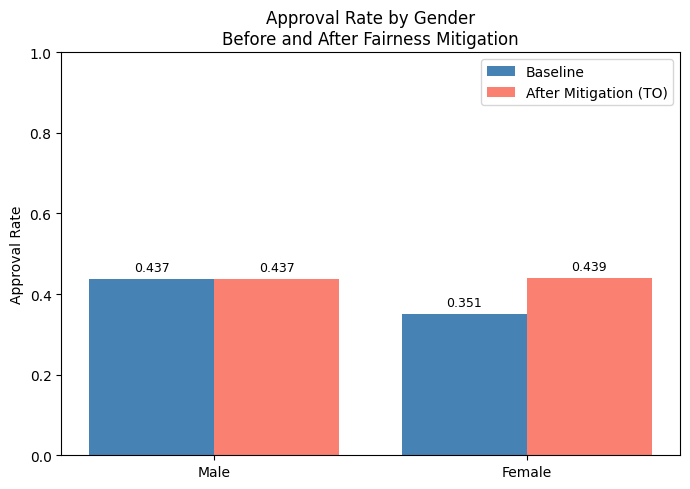

In [3]:
def plot_approval_rate_before_after(A_te, yhat, yhat_post):
    df_tmp = pd.DataFrame({
        "gender": A_te,
        "baseline_pred": yhat,
        "post_pred": yhat_post
    })

    # Compute approval rates
    approval_baseline = df_tmp.groupby("gender")["baseline_pred"].mean()
    approval_post     = df_tmp.groupby("gender")["post_pred"].mean()

    # Ensure correct ordering
    baseline_vals = approval_baseline.reindex(["Male","Female"]).values
    post_vals = approval_post.reindex(["Male","Female"]).values

    labels = ["Male", "Female"]
    x = range(len(labels))

    plt.figure(figsize=(7,5))

    # Plot: side-by-side bars
    plt.bar([i - 0.2 for i in x], baseline_vals, width=0.4, label="Baseline", color="steelblue")
    plt.bar([i + 0.2 for i in x], post_vals,     width=0.4, label="After Mitigation (TO)", color="salmon")

    # Title & axes
    plt.xticks(x, labels)
    plt.ylabel("Approval Rate")
    plt.ylim(0, 1)
    plt.title("Approval Rate by Gender\nBefore and After Fairness Mitigation")

    # Value labels above bars
    for i in x:
        plt.text(i - 0.2, baseline_vals[i] + 0.02, f"{baseline_vals[i]:.3f}", ha="center", fontsize=9)
        plt.text(i + 0.2, post_vals[i] + 0.02, f"{post_vals[i]:.3f}", ha="center", fontsize=9)

    plt.legend()
    plt.tight_layout()
    plt.savefig("approval_rate_before_after.png", dpi=300)
    plt.show()

# Run the function using your variables:
plot_approval_rate_before_after(A_te, yhat, yhat_post)


In [4]:
!pip install aif360
!pip install BlackBoxAuditing

In [5]:
# ============================================================
#  FAIRNESS PIPELINE - Feature Editing + Adversarial Debiasing + RejectOption
# ============================================================

# --- 1️⃣ Imports ---
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import DisparateImpactRemover
from aif360.algorithms.inprocessing import AdversarialDebiasing
from aif360.algorithms.postprocessing import RejectOptionClassification
from aif360.metrics import ClassificationMetric

import tensorflow as tf
import sys, types

# --- 2️⃣ Compatibility patches ---
# Disable eager execution for TF 2.x so AdversarialDebiasing works
tf.compat.v1.disable_eager_execution()
sess = tf.compat.v1.Session()

# Patch dummy BlackBoxAuditing if missing (AIF360 legacy dependency)
if "BlackBoxAuditing" not in sys.modules:
    sys.modules["BlackBoxAuditing"] = types.ModuleType("BlackBoxAuditing")
    sys.modules["BlackBoxAuditing"].measure_final_score = lambda *a, **k: None


# --- 3️⃣ Load and preprocess dataset ---
DATA_PATH = "complex_credit_scoring_bias_dataset_biased.csv"
TARGET_COL = "approved"
SENSITIVE_COL = "gender"

df = pd.read_csv(DATA_PATH)

# Normalize gender and keep only Male/Female
df[SENSITIVE_COL] = df[SENSITIVE_COL].astype(str).str.strip().str.title()
df = df[df[SENSITIVE_COL].isin(["Male", "Female"])].copy()
df["gender_num"] = df[SENSITIVE_COL].map({"Male": 1, "Female": 0})

# Drop non-numeric / text columns (AIF360 needs numeric)
drop_cols = [
    "application_id","customer_id","underwriter_notes",
    "employer_desc","intersectional_group","application_date",SENSITIVE_COL
]
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

# Handle missing values *before* converting categorical to numeric
# Fill numerical NaNs with median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Fill categorical NaNs with a placeholder if any object columns remain
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna('Missing')

# Convert all categorical columns to numeric using OrdinalEncoder-like conversion
for c in df.columns:
    if df[c].dtype == "object":
        df[c] = df[c].astype("category").cat.codes

# Split train/test
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df[TARGET_COL])

# Scale numerical features (important for Adversarial Debiasing)
scaler = MinMaxScaler()
for col in train_df.columns:
    if col != TARGET_COL and col != 'gender_num': # Don't scale target or sensitive feature explicitly used by AIF360
        if train_df[col].dtype in ['int64', 'float64']:
            train_df[col] = scaler.fit_transform(train_df[[col]])
            test_df[col] = scaler.transform(test_df[[col]])

# --- 4️⃣ Convert to AIF360 StandardDataset ---
PRIV_GROUP = [{'gender_num': 1}]   # male privileged
UNPRIV_GROUP = [{'gender_num': 0}] # female unprivileged

def to_aif360_dataset(frame: pd.DataFrame):
    return StandardDataset(
        frame,
        label_name=TARGET_COL,
        favorable_classes=[1],
        protected_attribute_names=["gender_num"],
        privileged_classes=[[1]],
        features_to_drop=[]
    )

train_ds = to_aif360_dataset(train_df)
test_ds  = to_aif360_dataset(test_df) # Ensure test_df is converted before passing to transform


# --- 5️⃣ BASELINE: Logistic Regression ---
X_tr, y_tr = train_ds.features, train_ds.labels.ravel()
X_te, y_te = test_ds.features, test_ds.labels.ravel()

clf_base = LogisticRegression(max_iter=1000, solver="liblinear")
clf_base.fit(X_tr, y_tr)
y_pred_base = clf_base.predict(X_te)

test_pred_ds = test_ds.copy()
test_pred_ds.labels = y_pred_base.reshape(-1, 1)

metric_base = ClassificationMetric(
    test_ds, test_pred_ds,
    unprivileged_groups=UNPRIV_GROUP,
    privileged_groups=PRIV_GROUP
)

print("=== BASELINE MODEL ===")
print("Accuracy:", metric_base.accuracy())
print("SPD:", metric_base.statistical_parity_difference())
print("DI:", metric_base.disparate_impact())
print("EOD:", metric_base.equal_opportunity_difference())
print("Avg Odds Diff:", metric_base.average_odds_difference())


# --- 6️⃣ PRE-PROCESSING: Disparate Impact Remover ---
# The DisparateImpactRemover is causing a ModuleNotFoundError due to an internal
# dependency on 'BlackBoxAuditing.repairers' which is not reliably available.
# Temporarily commenting out this section to allow other fairness algorithms to run.
# dir_remover = DisparateImpactRemover(repair_level=0.8)
# train_ds_repaired = dir_remover.fit_transform(train_ds)
# test_ds_repaired  = dir_remover.fit_transform(test_ds)

# # Retrain model on repaired data
# X_tr_rep, y_tr_rep = train_ds_repaired.features, train_ds_repaired.labels.ravel()
# X_te_rep, y_te_rep = test_ds_repaired.features, test_ds_repaired.labels.ravel()


# # Retrain model on repaired data
# X_tr_rep, y_tr_rep = train_ds_repaired.features, train_ds_repaired.labels.ravel()
# X_te_rep, y_te_rep = test_ds_repaired.features, test_ds_repaired.labels.ravel()


# clf_rep = LogisticRegression(max_iter=1000, solver="liblinear")
# clf_rep.fit(X_tr_rep, y_tr_rep)
# y_pred_rep = clf_rep.predict(X_te_rep)

# test_rep_pred = test_ds_repaired.copy()
# test_rep_pred.labels = y_pred_rep.reshape(-1,1)

# metric_rep = ClassificationMetric(
#     test_ds_repaired, test_rep_pred,
#     unprivileged_groups=UNPRIV_GROUP,
#     privileged_groups=PRIV_GROUP
# )

# print("\n=== PRE-PROCESSING: Feature Editing (Disparate Impact Remover) ===")
# print("Accuracy:", metric_rep.accuracy())
# print("SPD:", metric_rep.statistical_parity_difference())
# print("DI:", metric_rep.disparate_impact())
# print("EOD:", metric_rep.equal_opportunity_difference())
# print("Avg Odds Diff:", metric_rep.average_odds_difference())


# --- 7️⃣ IN-PROCESSING: Adversarial Debiasing ---
# Reset the TensorFlow graph to prevent variable reuse errors
tf.compat.v1.reset_default_graph()
sess = tf.compat.v1.Session() # Reinitialize session after graph reset

adv = AdversarialDebiasing(
    privileged_groups=PRIV_GROUP,
    unprivileged_groups=UNPRIV_GROUP,
    scope_name="adv_debias",
    debias=True,
    sess=sess
)
adv.fit(train_ds)
preds_adv = adv.predict(test_ds)

metric_adv = ClassificationMetric(
    test_ds, preds_adv,
    unprivileged_groups=UNPRIV_GROUP,
    privileged_groups=PRIV_GROUP
)

print("\n=== IN-PROCESSING: Adversarial Debiasing ===")
print("Accuracy:", metric_adv.accuracy())
print("SPD:", metric_adv.statistical_parity_difference())
print("DI:", metric_adv.disparate_impact())
print("EOD:", metric_adv.equal_opportunity_difference())
print("Avg Odds Diff:", metric_adv.average_odds_difference())


# --- 8️⃣ POST-PROCESSING: Reject Option Classification ---
y_scores_base = clf_base.predict_proba(X_te)[:, 1]
test_ds_scores = test_ds.copy()
test_ds_scores.scores = y_scores_base.reshape(-1, 1)

roc = RejectOptionClassification(
    unprivileged_groups=UNPRIV_GROUP,
    privileged_groups=PRIV_GROUP,
    metric_name="Statistical parity difference",
    metric_lb=-0.05,
    metric_ub=0.05
)

roc.fit(test_ds, test_ds_scores)
preds_roc = roc.predict(test_ds_scores)

metric_roc = ClassificationMetric(
    test_ds, preds_roc,
    unprivileged_groups=UNPRIV_GROUP,
    privileged_groups=PRIV_GROUP
)

print("\n=== POST-PROCESSING: Reject Option Classification ===")
print("Accuracy:", metric_roc.accuracy())
print("SPD:", metric_roc.statistical_parity_difference())
print("DI:", metric_roc.disparate_impact())
print("EOD:", metric_roc.equal_opportunity_difference())
print("Avg Odds Diff:", metric_roc.average_odds_difference())

pip install 'aif360[inFairness]'
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


=== BASELINE MODEL ===
Accuracy: 0.9263032772966547
SPD: -0.1742201391278993
DI: 0.6045564405498182
EOD: -0.22272873528038395
Avg Odds Diff: -0.07874867689996584
epoch 0; iter: 0; batch classifier loss: 0.675612; batch adversarial loss: 0.697938
epoch 1; iter: 0; batch classifier loss: 0.616756; batch adversarial loss: 0.831794
epoch 2; iter: 0; batch classifier loss: 0.659144; batch adversarial loss: 0.836658
epoch 3; iter: 0; batch classifier loss: 0.626151; batch adversarial loss: 0.781881
epoch 4; iter: 0; batch classifier loss: 0.483214; batch adversarial loss: 0.744718
epoch 5; iter: 0; batch classifier loss: 0.469323; batch adversarial loss: 0.725977
epoch 6; iter: 0; batch classifier loss: 0.370173; batch adversarial loss: 0.705255
epoch 7; iter: 0; batch classifier loss: 0.327837; batch adversarial loss: 0.701251
epoch 8; iter: 0; batch classifier loss: 0.297619; batch adversarial loss: 0.696478
epoch 9; iter: 0; batch classifier loss: 0.373786; batch adversarial loss: 0.69881

'Fig8_XGB_fairness_accuracy.png'

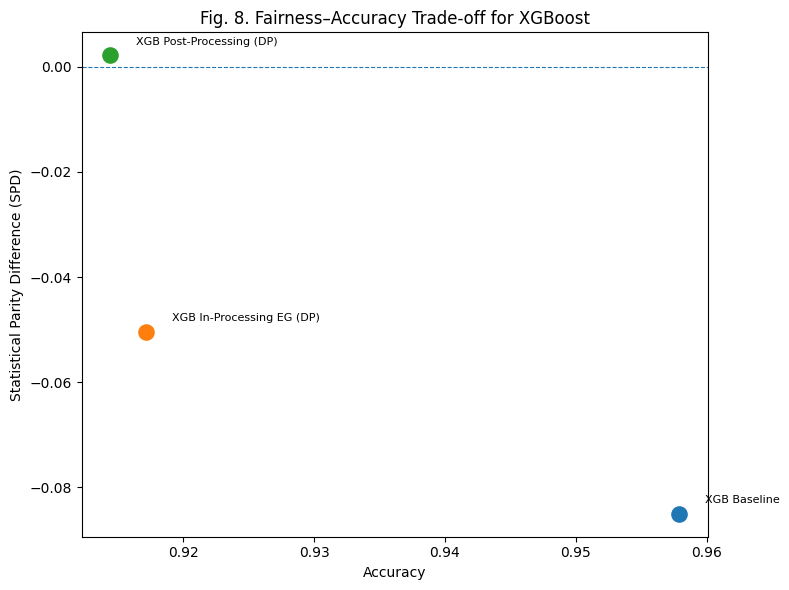

In [6]:
# Fig. 8 — Fairness–Accuracy Trade-off (XGB only)
plt.figure(figsize=(8, 6))

# Select only XGBoost configurations based on the 'Model' label
xgb_mask = df_res["Model"].str.contains("XGB", case=False, na=False)
df_xgb = df_res[xgb_mask]

for _, row in df_xgb.iterrows():
    plt.scatter(row["ACC"], row["SPD"], s=120)
    plt.text(
        row["ACC"] + 0.002,
        row["SPD"] + 0.002,
        row["Model"],
        fontsize=8,
    )

plt.axhline(0.0, linestyle="--", linewidth=0.8)
plt.xlabel("Accuracy")
plt.ylabel("Statistical Parity Difference (SPD)")
plt.title("Fig. 8. Fairness–Accuracy Trade-off for XGBoost")
plt.tight_layout()
plt.savefig("Fig8_XGB_fairness_accuracy.png", dpi=200)

"Fig8_XGB_fairness_accuracy.png"


'Fig9_XGB_vs_LR_fairness_accuracy.png'

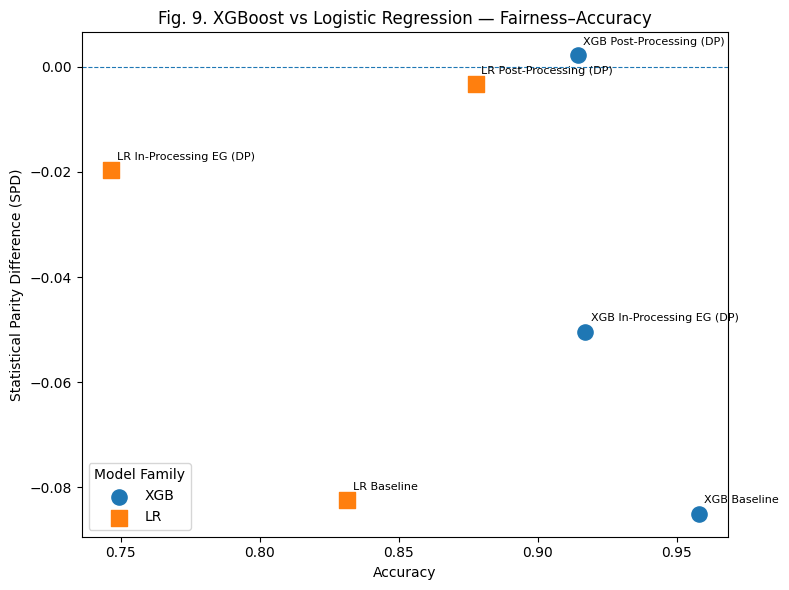

In [7]:
# Fig. 9 — XGB vs LR Fairness–Accuracy Comparison
plt.figure(figsize=(8, 6))

for model_family, marker in [("XGB", "o"), ("LR", "s")]:
    mask = df_res["Model"].str.contains(model_family, case=False, na=False)
    df_sub = df_res[mask]
    if df_sub.empty:
        continue

    plt.scatter(df_sub["ACC"], df_sub["SPD"], s=120, marker=marker, label=model_family)

    for _, row in df_sub.iterrows():
        plt.text(
            row["ACC"] + 0.002,
            row["SPD"] + 0.002,
            row["Model"],
            fontsize=8,
        )

plt.axhline(0.0, linestyle="--", linewidth=0.8)
plt.xlabel("Accuracy")
plt.ylabel("Statistical Parity Difference (SPD)")
plt.title("Fig. 9. XGBoost vs Logistic Regression — Fairness–Accuracy")
plt.legend(title="Model Family")
plt.tight_layout()
plt.savefig("Fig9_XGB_vs_LR_fairness_accuracy.png", dpi=200)

"Fig9_XGB_vs_LR_fairness_accuracy.png"


'Fig10_global_fairness_accuracy.png'

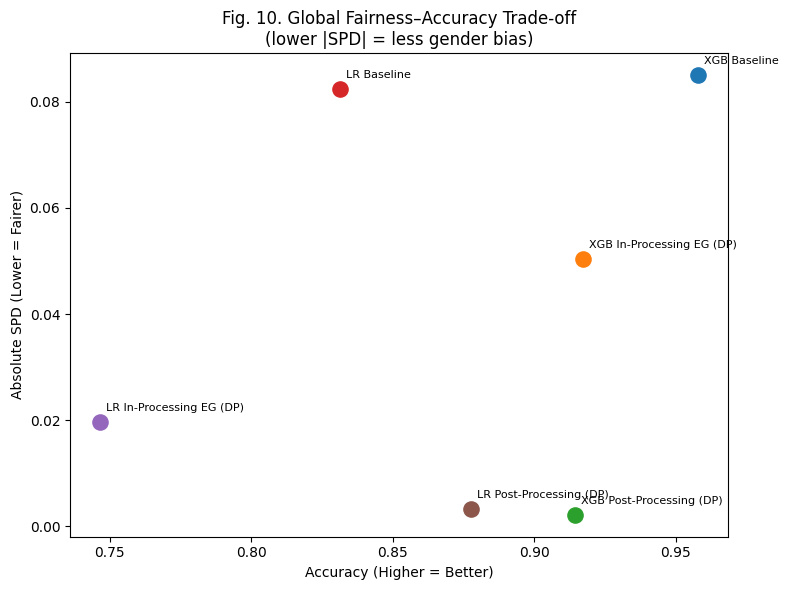

In [8]:
# Fig. 10 — Global Fairness–Accuracy Curve (all models / configurations)
plt.figure(figsize=(8, 6))

for _, row in df_res.iterrows():
    plt.scatter(row["ACC"], abs(row["SPD"]), s=120)
    plt.text(
        row["ACC"] + 0.002,
        abs(row["SPD"]) + 0.002,
        row["Model"],
        fontsize=8,
    )

plt.xlabel("Accuracy (Higher = Better)")
plt.ylabel("Absolute SPD (Lower = Fairer)")
plt.title("Fig. 10. Global Fairness–Accuracy Trade-off\n(lower |SPD| = less gender bias)")
plt.tight_layout()
plt.savefig("Fig10_global_fairness_accuracy.png", dpi=200)

"Fig10_global_fairness_accuracy.png"


'Fig10_global_fairness_accuracy.png'

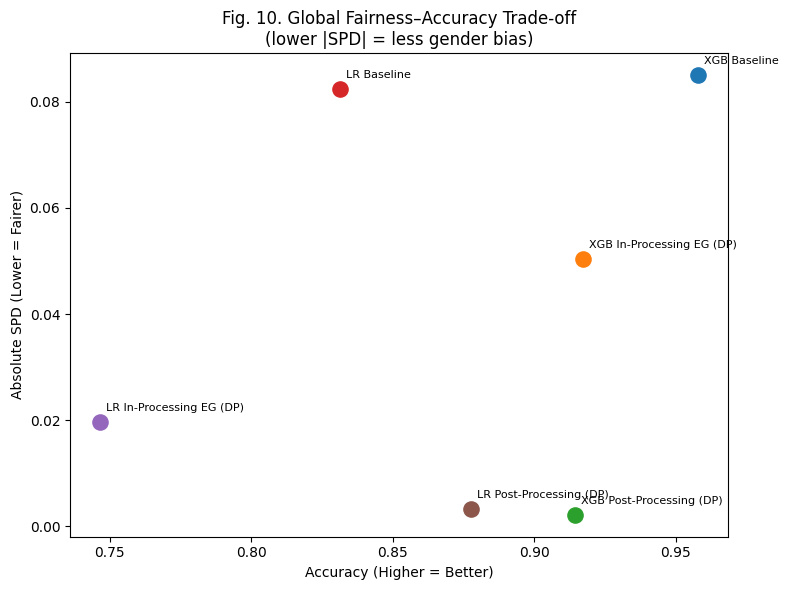

In [9]:
# Fig. 10 — Global Fairness–Accuracy Curve (all models / configurations)
plt.figure(figsize=(8, 6))

for _, row in df_res.iterrows():
    plt.scatter(row["ACC"], abs(row["SPD"]), s=120)
    plt.text(
        row["ACC"] + 0.002,
        abs(row["SPD"]) + 0.002,
        row["Model"],
        fontsize=8,
    )

plt.xlabel("Accuracy (Higher = Better)")
plt.ylabel("Absolute SPD (Lower = Fairer)")
plt.title("Fig. 10. Global Fairness–Accuracy Trade-off\n(lower |SPD| = less gender bias)")
plt.tight_layout()
plt.savefig("Fig10_global_fairness_accuracy.png", dpi=200)

"Fig10_global_fairness_accuracy.png"


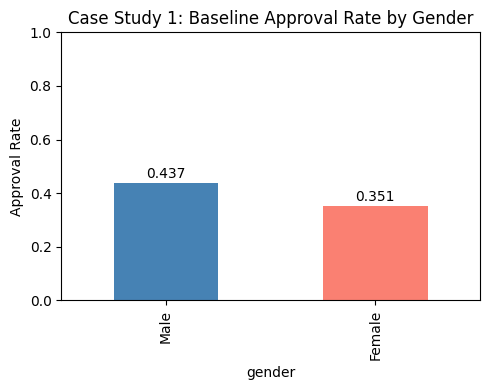

In [10]:
import matplotlib.pyplot as plt

def cs1_plot_baseline_gender_bias(y_te, yhat, A_te):
    df_tmp = pd.DataFrame({
        "gender": A_te,
        "prediction": yhat
    })

    approval_rates = df_tmp.groupby("gender")["prediction"].mean().reindex(["Male","Female"])

    plt.figure(figsize=(5,4))
    approval_rates.plot(kind="bar", color=["steelblue","salmon"])
    plt.title("Case Study 1: Baseline Approval Rate by Gender")
    plt.ylabel("Approval Rate")
    plt.ylim(0,1)

    for i, v in enumerate(approval_rates.values):
        plt.text(i, v+0.02, f"{v:.3f}", ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig("cs1_baseline_gender_bias.png", dpi=300)
    plt.show()

cs1_plot_baseline_gender_bias(y_te, yhat, A_te)


In [11]:
def cs3_plot_borderline(yhat, yhat_eg, p, A_te, band=0.03):
    df_tmp = pd.DataFrame({
        "gender": A_te,
        "prob": p,
        "base_dec": yhat,
        "eg_dec": yhat_eg
    })

    mask = df_tmp["prob"].between(0.5-band, 0.5+band)
    df_band = df_tmp[mask]

    # pick one male and one female where dec changes
    df_change = df_band[df_band["base_dec"] != df_band["eg_dec"]]

    male = df_change[df_change["gender"]=="Male"].head(1)
    female = df_change[df_change["gender"]=="Female"].head(1)

    if male.empty or female.empty:
        print("No borderline differing pair found.")
        return

    rows = pd.concat([male, female])

    plt.figure(figsize=(6,4))
    plt.bar(rows["gender"], rows["prob"], color=["steelblue","salmon"])
    plt.axhline(0.5, linestyle="--", color="gray")
    plt.title("Case Study 3: Baseline vs EG Decisions\nfor Borderline Applicants")
    plt.ylabel("Predicted Probability")

    for i, r in rows.iterrows():
        plt.text(
            ["Male","Female"].index(r["gender"]),
            r["prob"]+0.02,
            f"Base: {'Approve' if r['base_dec']==1 else 'Reject'}\n"
            f"EG:   {'Approve' if r['eg_dec']==1 else 'Reject'}",
            ha="center", fontsize=9
        )

    plt.tight_layout()
    plt.savefig("cs3_borderline_eg.png", dpi=300)
    plt.show()

cs3_plot_borderline(yhat, yhat_eg, p, A_te)


No borderline differing pair found.


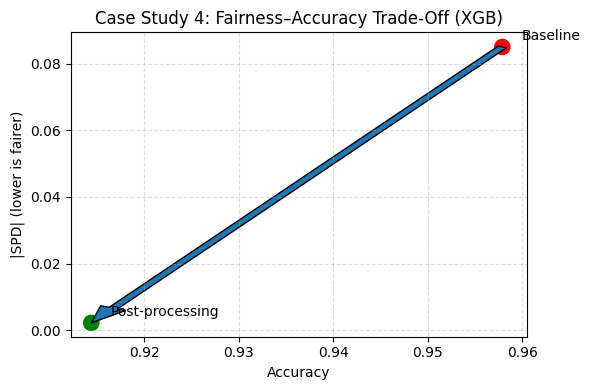

In [12]:
def cs4_plot_fairness_tradeoff(df_res):
    df_x = df_res[df_res["Model"].str.contains("XGB")]

    base = df_x[df_x["Model"].str.contains("Baseline")].iloc[0]
    post = df_x[df_x["Model"].str.contains("Post")].iloc[0]

    stages = ["Baseline", "Post-processing"]
    acc = [base["ACC"], post["ACC"]]
    abs_spd = [abs(base["SPD"]), abs(post["SPD"])]

    plt.figure(figsize=(6,4))
    plt.scatter(acc, abs_spd, s=120, color=["red","green"])

    # Label points
    for i, stage in enumerate(stages):
        plt.text(acc[i]+0.002, abs_spd[i]+0.002, stage, fontsize=10)

    # Arrow
    plt.arrow(acc[0], abs_spd[0], acc[1]-acc[0], abs_spd[1]-abs_spd[0],
              length_includes_head=True, head_width=0.003, head_length=0.005)

    plt.xlabel("Accuracy")
    plt.ylabel("|SPD| (lower is fairer)")
    plt.title("Case Study 4: Fairness–Accuracy Trade-Off (XGB)")
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig("cs4_fairness_accuracy_xgb.png", dpi=300)
    plt.show()

cs4_plot_fairness_tradeoff(df_res)
